# 피처 선택 — Spearman + MI + Lasso
Team 반갑다모 | 2026.07.01

> Y_Quality 기반 피처 선택 → Y_Class 분류 모델에 적용
> 2개 이상 방법에서 공통 선정된 피처만 최종 사용

---

### 피처 선택 방법
| 방법 | 원리 | 특징 |
|------|------|------|
| Spearman 상관계수 | 순위 기반 단조 관계 측정 | 비정규분포·이상치에 강건 |
| Mutual Information | 정보이론 기반 불확실성 감소 | 비선형 관계까지 탐지 |
| LassoCV | L1 정규화 회귀 계수 선택 | 교차검증으로 과적합 방지 |

### 전략
- **A_31**: CW 강화 (class_weight={0:4,1:1,2:4}) 유지
- **T_31**: Baseline 유지 (SMOTE 역효과 확인)
- 두 제품 모두 피처 선택 후 LightGBM 재학습


## 0. 환경 설정

In [1]:
import sys, subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'lightgbm', 'koreanize-matplotlib', '-q'])

import koreanize_matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, recall_score, confusion_matrix
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from scipy.stats import spearmanr
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
print('환경 설정 완료')

환경 설정 완료


## 1. 데이터 로드

In [2]:
a31 = pd.read_csv('A_31_preprocessed.csv', low_memory=False)
t31 = pd.read_csv('TO_31_preprocessed.csv', low_memory=False)

DROP_COLS = ['PRODUCT_ID', 'Y_Class', 'Y_Quality', 'TIMESTAMP', 'PRODUCT_CODE']

def get_XY(df):
    feat_cols = [c for c in df.columns
                 if c not in DROP_COLS and c in df.columns]
    X = df[feat_cols]
    y_cls = df['Y_Class']
    y_qlt = df['Y_Quality']
    return X, y_cls, y_qlt

X_a, y_a_cls, y_a_qlt = get_XY(a31)
X_t, y_t_cls, y_t_qlt = get_XY(t31)

print(f'A_31  : {X_a.shape} | Y_Class {y_a_cls.value_counts().sort_index().to_dict()}')
print(f'T_31+O_31: {X_t.shape} | Y_Class {y_t_cls.value_counts().sort_index().to_dict()}')

A_31  : (316, 1966) | Y_Class {0: 76, 1: 150, 2: 90}
T_31+O_31: (592, 569) | Y_Class {0: 48, 1: 490, 2: 54}


---
## 2. 피처 선택 — Spearman + MI + Lasso

### ⚠️ 중요: train 데이터 기준으로만 피처 선택
피처 선택도 전체 데이터로 하면 누수 발생
→ Stratified KFold의 train fold 기준으로 선택


In [3]:
def select_features(X, y_qlt, label,
                    spearman_top=20, mi_top=20, lasso_alpha_list=None,
                    min_methods=2):
    print(f'\n{"-"*50}')
    print(f'[{label}] 피처 선택 시작 (전체 {X.shape[1]}개)')

    # 결측 impute (피처 선택 도구는 NaN 불가)
    imp = SimpleImputer(strategy='median')
    X_imp = pd.DataFrame(imp.fit_transform(X), columns=X.columns)

    feat_cols = [c for c in X_imp.columns if c.startswith('X_')]
    X_feat = X_imp[feat_cols]

    # ① Spearman 상관계수
    print('  ① Spearman 상관계수 계산 중...')
    spearman_scores = {}
    for col in feat_cols:
        try:
            r, p = spearmanr(X_feat[col], y_qlt)
            if p < 0.05:  # 유의미한 것만
                spearman_scores[col] = abs(r)
        except:
            pass
    spearman_top_feats = sorted(spearman_scores.items(),
                                key=lambda x: -x[1])[:spearman_top]
    spearman_set = set([f for f, _ in spearman_top_feats])
    print(f'     선정: {len(spearman_set)}개')

    # ② Mutual Information
    print('  ② Mutual Information 계산 중...')
    mi_scores = mutual_info_regression(X_feat, y_qlt, random_state=42)
    mi_df = pd.DataFrame({'feature': feat_cols, 'mi': mi_scores})
    mi_df = mi_df.sort_values('mi', ascending=False)
    mi_set = set(mi_df.head(mi_top)['feature'].tolist())
    print(f'     선정: {len(mi_set)}개')

    # ③ LassoCV
    print('  ③ LassoCV 계산 중...')
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_feat)
    lasso = LassoCV(cv=5, random_state=42, max_iter=5000)
    lasso.fit(X_scaled, y_qlt)
    lasso_coef = pd.Series(np.abs(lasso.coef_), index=feat_cols)
    lasso_set = set(lasso_coef[lasso_coef > 0].index.tolist())
    print(f'     선정: {len(lasso_set)}개')

    # 교집합 (2개 이상 방법 공통)
    all_sets = [spearman_set, mi_set, lasso_set]
    from collections import Counter
    all_feats = [f for s in all_sets for f in s]
    count = Counter(all_feats)
    final_feats = [f for f, c in count.items() if c >= min_methods]

    # 비X_ 컬럼 (LINE 인코딩 등) 추가
    non_x_cols = [c for c in X_imp.columns if not c.startswith('X_')]
    final_feats_all = final_feats + non_x_cols

    print(f'\n  최종 선정:')
    print(f'    Spearman: {len(spearman_set)}개')
    print(f'    MI:       {len(mi_set)}개')
    print(f'    Lasso:    {len(lasso_set)}개')
    print(f'    2개+ 공통: {len(final_feats)}개 (X_ 피처)')
    print(f'    최종 (LINE 포함): {len(final_feats_all)}개')
    print(f'    선정 피처: {final_feats[:10]}...')

    return final_feats_all, {
        'spearman': spearman_scores,
        'mi': dict(zip(feat_cols, mi_scores)),
        'lasso': lasso_coef.to_dict(),
        'spearman_set': spearman_set,
        'mi_set': mi_set,
        'lasso_set': lasso_set,
        'final': set(final_feats)
    }

selected_a, scores_dict_a = select_features(X_a, y_a_qlt, 'A_31')
selected_t, scores_dict_t = select_features(X_t, y_t_qlt, 'T_31+O_31')


--------------------------------------------------
[A_31] 피처 선택 시작 (전체 1966개)
  ① Spearman 상관계수 계산 중...


     선정: 20개
  ② Mutual Information 계산 중...


     선정: 20개
  ③ LassoCV 계산 중...


     선정: 112개

  최종 선정:
    Spearman: 20개
    MI:       20개
    Lasso:    112개
    2개+ 공통: 9개 (X_ 피처)
    최종 (LINE 포함): 12개
    선정 피처: ['X_240', 'X_285', 'X_335', 'X_1849', 'X_2841', 'X_1010', 'X_318', 'X_1012', 'X_189']...

--------------------------------------------------
[T_31+O_31] 피처 선택 시작 (전체 569개)
  ① Spearman 상관계수 계산 중...


     선정: 20개
  ② Mutual Information 계산 중...


     선정: 20개
  ③ LassoCV 계산 중...


     선정: 31개

  최종 선정:
    Spearman: 20개
    MI:       20개
    Lasso:    31개
    2개+ 공통: 11개 (X_ 피처)
    최종 (LINE 포함): 12개
    선정 피처: ['X_835', 'X_697', 'X_458', 'X_786', 'X_121', 'X_63', 'X_73', 'X_468', 'X_90', 'X_120']...


---
## 3. 시각화 — 피처 선택 결과

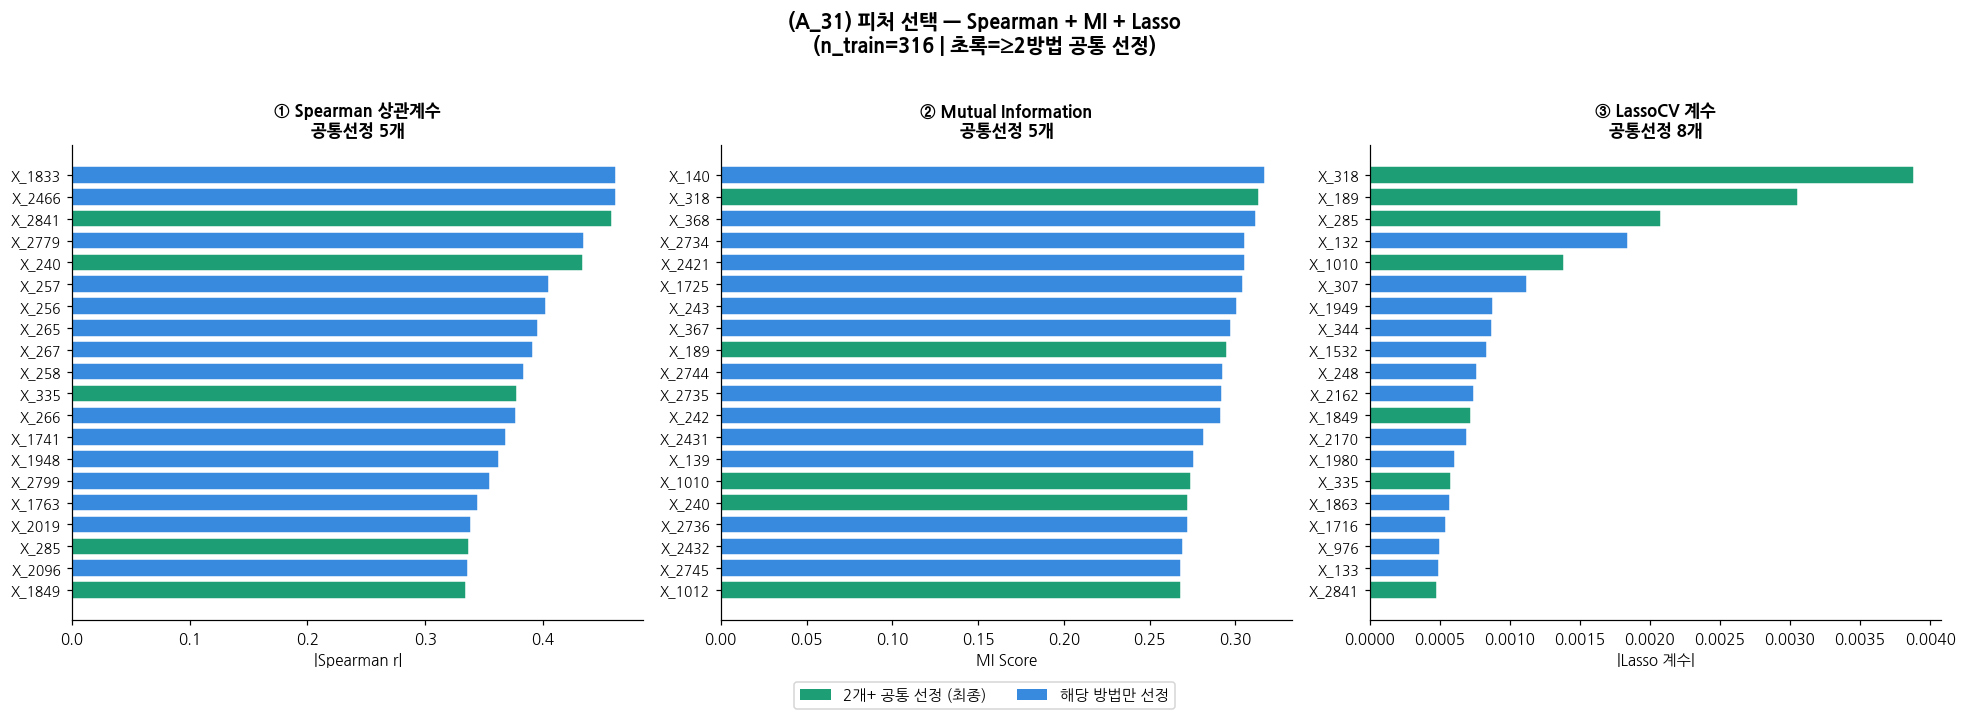

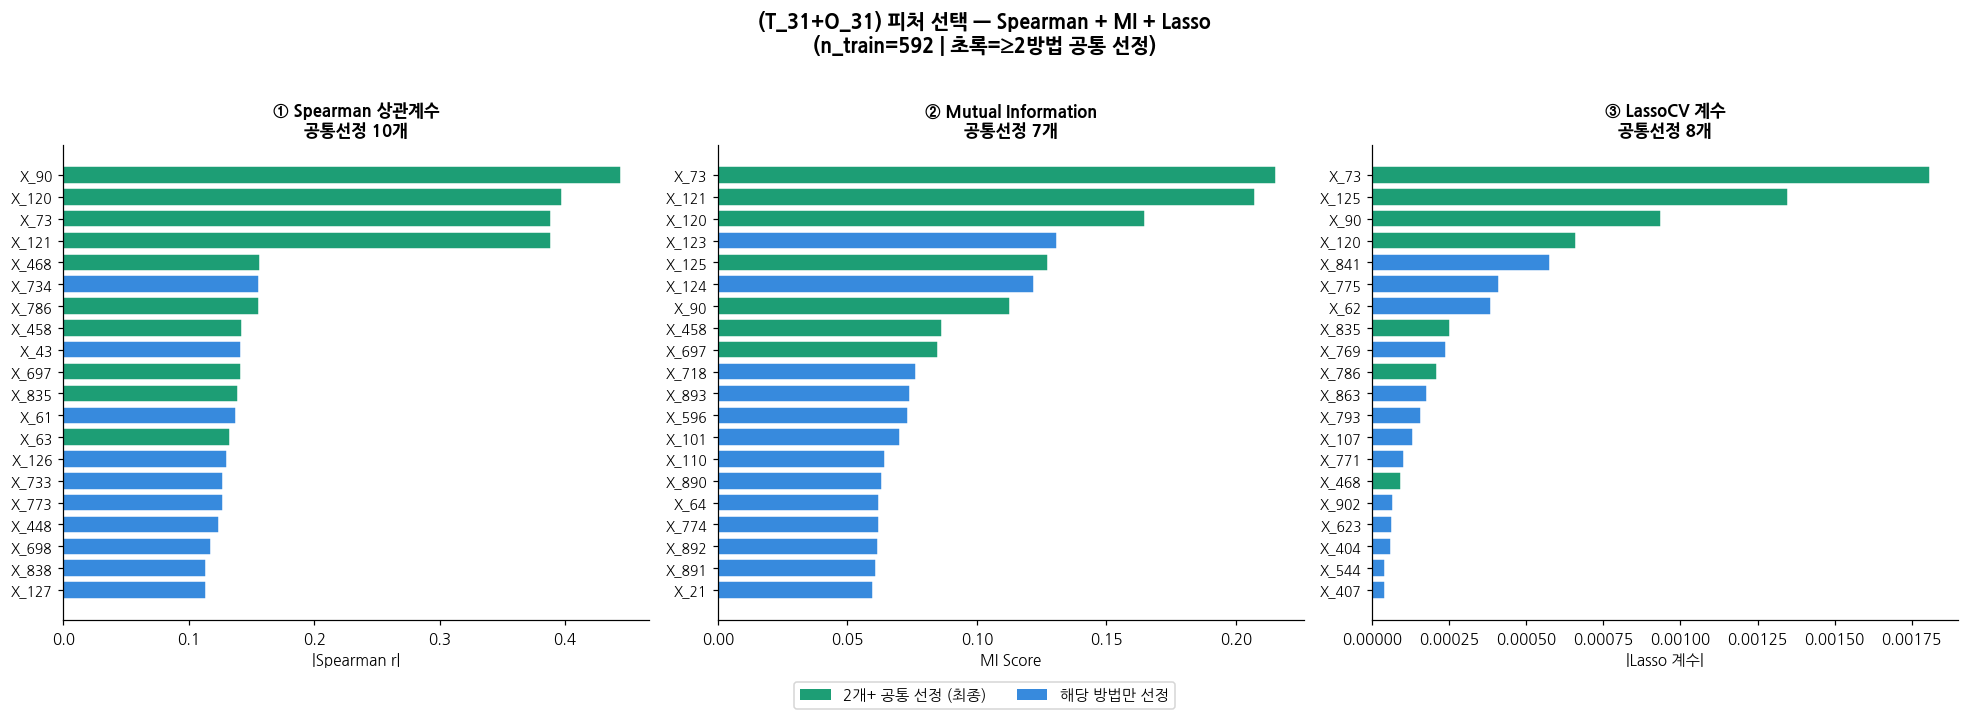

In [4]:
def plot_feature_selection(scores_dict, label):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    final = scores_dict['final']
    sp_set = scores_dict['spearman_set']
    mi_set = scores_dict['mi_set']
    lasso_set = scores_dict['lasso_set']

    # Spearman
    ax = axes[0]
    sp_items = sorted(scores_dict['spearman'].items(), key=lambda x: -x[1])[:20]
    feats = [f for f, _ in sp_items]
    vals  = [v for _, v in sp_items]
    colors = ['#1D9E75' if f in final else '#378ADD' for f in feats]
    ax.barh(range(len(feats)), vals, color=colors, edgecolor='white')
    ax.set_yticks(range(len(feats)))
    ax.set_yticklabels(feats, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f'① Spearman 상관계수\n공통선정 {len(sp_set&final)}개', fontsize=11, fontweight='bold')
    ax.set_xlabel('|Spearman r|')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # MI
    ax = axes[1]
    mi_items = sorted(scores_dict['mi'].items(), key=lambda x: -x[1])[:20]
    feats = [f for f, _ in mi_items]
    vals  = [v for _, v in mi_items]
    colors = ['#1D9E75' if f in final else '#378ADD' for f in feats]
    ax.barh(range(len(feats)), vals, color=colors, edgecolor='white')
    ax.set_yticks(range(len(feats)))
    ax.set_yticklabels(feats, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f'② Mutual Information\n공통선정 {len(mi_set&final)}개', fontsize=11, fontweight='bold')
    ax.set_xlabel('MI Score')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Lasso
    ax = axes[2]
    lasso_items = sorted(scores_dict['lasso'].items(), key=lambda x: -x[1])
    lasso_nonzero = [(f, v) for f, v in lasso_items if v > 0][:20]
    if lasso_nonzero:
        feats = [f for f, _ in lasso_nonzero]
        vals  = [v for _, v in lasso_nonzero]
        colors = ['#1D9E75' if f in final else '#378ADD' for f in feats]
        ax.barh(range(len(feats)), vals, color=colors, edgecolor='white')
        ax.set_yticks(range(len(feats)))
        ax.set_yticklabels(feats, fontsize=9)
        ax.invert_yaxis()
    ax.set_title(f'③ LassoCV 계수\n공통선정 {len(lasso_set&final)}개', fontsize=11, fontweight='bold')
    ax.set_xlabel('|Lasso 계수|')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    from matplotlib.patches import Patch
    legend = [Patch(facecolor='#1D9E75', label='2개+ 공통 선정 (최종)'),
              Patch(facecolor='#378ADD', label='해당 방법만 선정')]
    fig.legend(handles=legend, loc='lower center', ncol=2, fontsize=10,
               bbox_to_anchor=(0.5, -0.05))

    plt.suptitle(f'({label}) 피처 선택 — Spearman + MI + Lasso\n'
                 f'(n_train={len(X_a) if "A" in label else len(X_t)} | '
                 f'초록=≥2방법 공통 선정)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_feature_selection(scores_dict_a, 'A_31')
plot_feature_selection(scores_dict_t, 'T_31+O_31')

---
## 4. 선택된 피처로 모델 재학습

- **A_31**: class_weight={0:4, 1:1, 2:4} (SMOTE 실험 결과 반영)
- **T_31**: class_weight='balanced' (Baseline 유지)


In [5]:
def run_with_selected(X, y_cls, selected_feats, label, cw='balanced', n_splits=5):
    print(f'\n{"-"*50}')
    print(f'[{label}] 선택 피처로 재학습')
    print(f'  피처 수: {X.shape[1]} -> {len(selected_feats)}개')

    # 선택된 피처만 추출
    avail = [c for c in selected_feats if c in X.columns]
    X_sel = X[avail]

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof = np.zeros(len(y_cls))
    imp_sum = np.zeros(len(avail))

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_sel, y_cls)):
        X_tr, X_val = X_sel.iloc[tr_idx], X_sel.iloc[val_idx]
        y_tr, y_val = y_cls.iloc[tr_idx], y_cls.iloc[val_idx]
        model = lgb.LGBMClassifier(
            n_estimators=500, learning_rate=0.05,
            num_leaves=31, class_weight=cw,
            random_state=42, verbose=-1
        )
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False),
                             lgb.log_evaluation(-1)])
        oof[val_idx] = model.predict(X_val)
        imp_sum += model.feature_importances_

    f1  = f1_score(y_cls, oof, average='macro')
    r0  = recall_score(y_cls, oof, labels=[0], average='macro')
    r2  = recall_score(y_cls, oof, labels=[2], average='macro')
    print(f'  Macro F1      : {f1:.4f}')
    print(f'  Class 0 Recall: {r0:.4f}')
    print(f'  Class 2 Recall: {r2:.4f}')

    return oof, imp_sum/n_splits, {'macro_f1': f1, 'recall_0': r0, 'recall_2': r2}, avail

# A_31: CW 강화
oof_a, imp_a, res_a, feats_a = run_with_selected(
    X_a, y_a_cls, selected_a, 'A_31', cw={0:4,1:1,2:4})

# T_31: Baseline 유지
oof_t, imp_t, res_t, feats_t = run_with_selected(
    X_t, y_t_cls, selected_t, 'T_31+O_31', cw='balanced')


--------------------------------------------------
[A_31] 선택 피처로 재학습
  피처 수: 1966 -> 12개


  Macro F1      : 0.6310
  Class 0 Recall: 0.8158
  Class 2 Recall: 0.8778

--------------------------------------------------
[T_31+O_31] 선택 피처로 재학습
  피처 수: 569 -> 12개


  Macro F1      : 0.6112
  Class 0 Recall: 0.4792
  Class 2 Recall: 0.4815


---
## 5. Baseline 대비 성능 비교

In [6]:
BASELINE = {
    'A_31':      {'macro_f1': 0.6995, 'recall_0': 0.6711, 'recall_2': 0.7111},
    'T_31+O_31': {'macro_f1': 0.6303, 'recall_0': 0.3750, 'recall_2': 0.3519},
}

print('=' * 60)
print('피처 선택 전후 성능 비교')
print('=' * 60)

for product, res, bl in [
    ('A_31', res_a, BASELINE['A_31']),
    ('T_31+O_31', res_t, BASELINE['T_31+O_31'])
]:
    print(f'\n[{product}]')
    print(f"  {'':15} {'Macro F1':>10} {'Class0 Recall':>14} {'Class2 Recall':>14}")
    print(f"  {'-'*57}")
    print(f"  {'Baseline':15} {bl['macro_f1']:>10.4f} {bl['recall_0']:>14.4f} {bl['recall_2']:>14.4f}")
    print(f"  {'피처선택 후':15} {res['macro_f1']:>10.4f} {res['recall_0']:>14.4f} {res['recall_2']:>14.4f}")
    diff_f1 = res['macro_f1'] - bl['macro_f1']
    diff_r0 = res['recall_0'] - bl['recall_0']
    diff_r2 = res['recall_2'] - bl['recall_2']
    print(f"  {'변화':15} {diff_f1:>+10.4f} {diff_r0:>+14.4f} {diff_r2:>+14.4f}")

피처 선택 전후 성능 비교

[A_31]
                    Macro F1  Class0 Recall  Class2 Recall
  ---------------------------------------------------------
  Baseline            0.6995         0.6711         0.7111
  피처선택 후              0.6310         0.8158         0.8778
  변화                 -0.0685        +0.1447        +0.1667

[T_31+O_31]
                    Macro F1  Class0 Recall  Class2 Recall
  ---------------------------------------------------------
  Baseline            0.6303         0.3750         0.3519
  피처선택 후              0.6112         0.4792         0.4815
  변화                 -0.0191        +0.1042        +0.1296


---
## 6. 피처 선택 후 Confusion Matrix & Importance

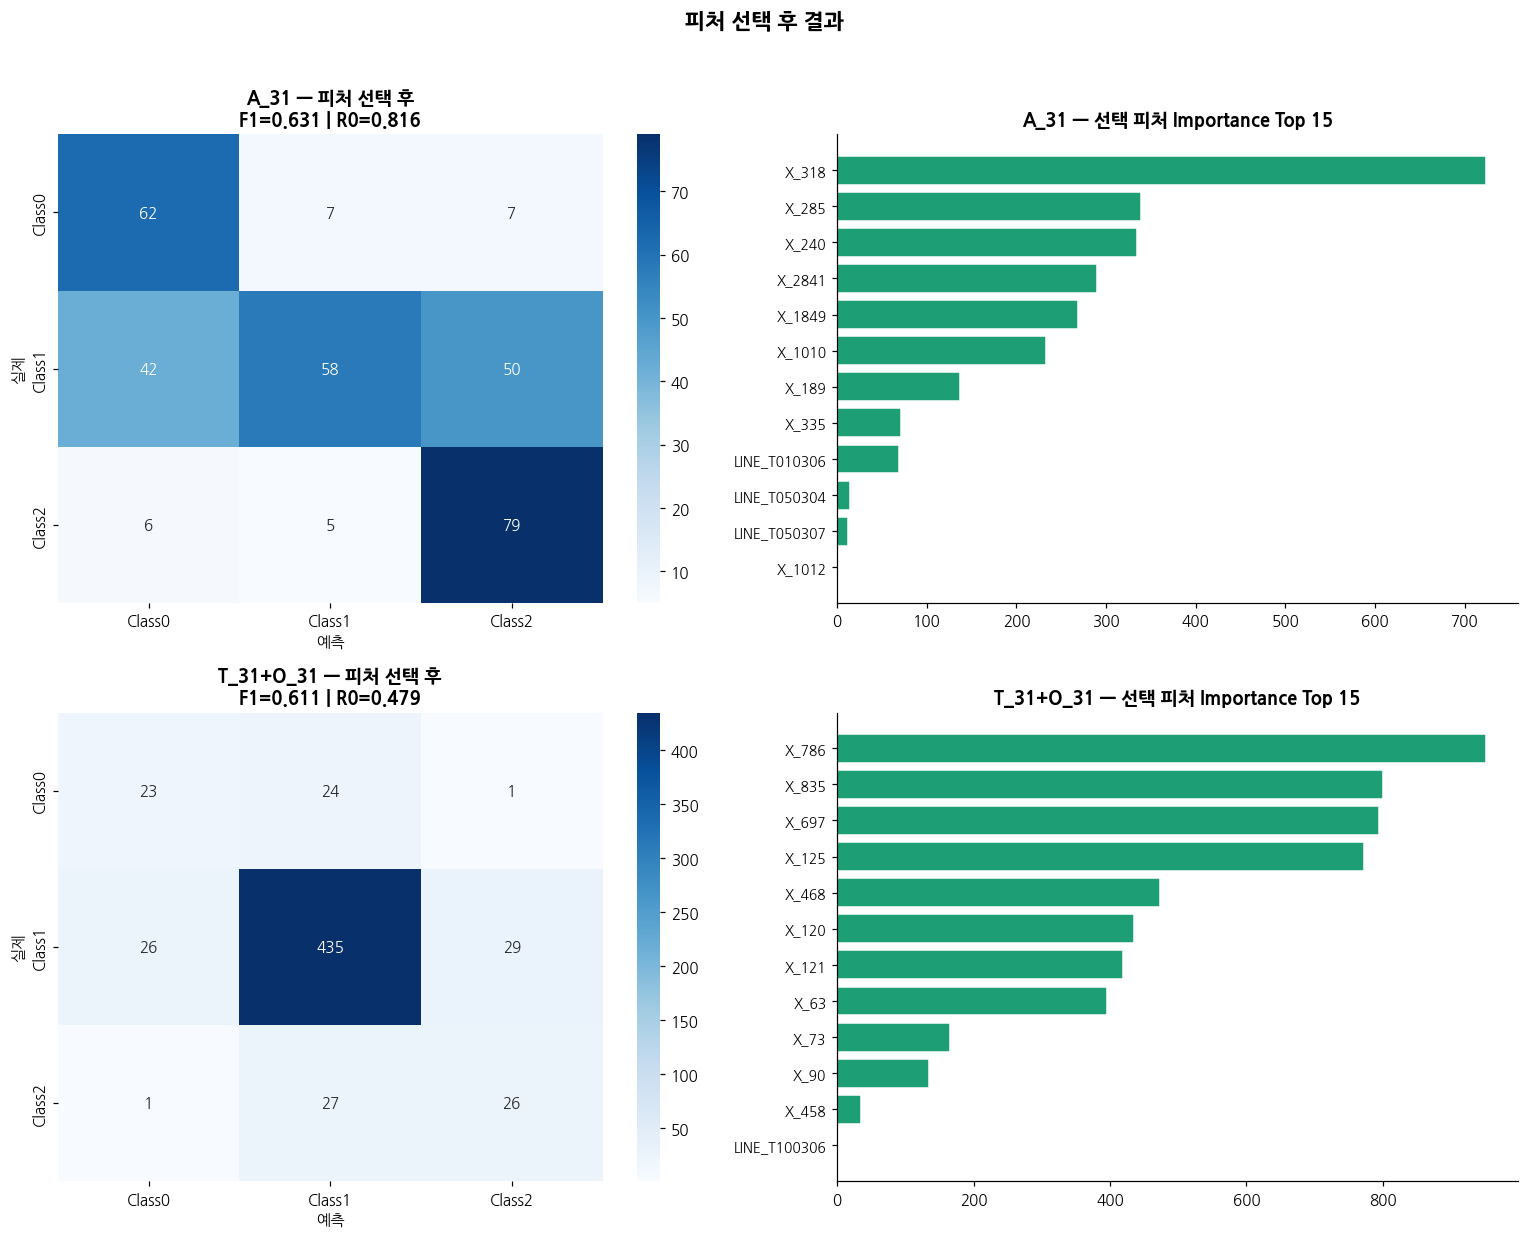

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for row, (product, y, oof) in enumerate([
    ('A_31', y_a_cls, oof_a),
    ('T_31+O_31', y_t_cls, oof_t)
]):
    # Confusion Matrix
    ax = axes[row, 0]
    cm = confusion_matrix(y, oof)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Class0','Class1','Class2'],
                yticklabels=['Class0','Class1','Class2'])
    res = res_a if 'A' in product else res_t
    ax.set_title(f'{product} — 피처 선택 후\nF1={res["macro_f1"]:.3f} | R0={res["recall_0"]:.3f}',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('실제')
    ax.set_xlabel('예측')

    # Feature Importance
    ax = axes[row, 1]
    imp = imp_a if 'A' in product else imp_t
    feats = feats_a if 'A' in product else feats_t
    imp_df = pd.DataFrame({'feature': feats, 'importance': imp})
    imp_df = imp_df.sort_values('importance', ascending=False).head(15)
    ax.barh(range(len(imp_df)), imp_df['importance'].values,
            color='#1D9E75', edgecolor='white')
    ax.set_yticks(range(len(imp_df)))
    ax.set_yticklabels(imp_df['feature'].values, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f'{product} — 선택 피처 Importance Top 15', fontsize=12, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('피처 선택 후 결과', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. 인사이트 & 다음 단계

In [8]:
print('=' * 55)
print('피처 선택 인사이트')
print('=' * 55)

for product, res, bl, selected in [
    ('A_31', res_a, BASELINE['A_31'], selected_a),
    ('T_31+O_31', res_t, BASELINE['T_31+O_31'], selected_t)
]:
    diff = res['macro_f1'] - bl['macro_f1']
    x_feats = [c for c in selected if c.startswith('X_')]
    print(f'\n[{product}]')
    print(f'  피처 수 감소: -> {len(x_feats)}개')
    if diff > 0.01:
        print(f'  F1 {diff:+.4f} -> 피처 선택 효과 있음!')
    elif diff > -0.01:
        print(f'  F1 {diff:+.4f} -> 피처 수 줄이면서 성능 유지')
    else:
        print(f'  F1 {diff:+.4f} -> 성능 하락. top_n 조정 필요')

print('\n' + '=' * 55)
print('다음 단계')
print('=' * 55)
print('  → Optuna 하이퍼파라미터 튜닝 (최고 전략 기준)')

피처 선택 인사이트

[A_31]
  피처 수 감소: -> 9개
  F1 -0.0685 -> 성능 하락. top_n 조정 필요

[T_31+O_31]
  피처 수 감소: -> 11개
  F1 -0.0191 -> 성능 하락. top_n 조정 필요

다음 단계
  → Optuna 하이퍼파라미터 튜닝 (최고 전략 기준)


---
## 8. top_n 실험 — 최적 피처 수 탐색

> 튜터 권고: 60개 그룹으로 축소 가능
> top_n = 20 / 40 / 60 / 80 순으로 실험


In [9]:
TOP_N_LIST = [20, 40, 60, 80]

# A_31: CW 강화 / T_31: Baseline 유지
topn_results = {'A_31': {}, 'T_31+O_31': {}}

for top_n in TOP_N_LIST:
    print(f'\n{"-"*50}')
    print(f'top_n = {top_n}')

    for product, X, y_cls, y_qlt, cw in [
        ('A_31', X_a, y_a_cls, y_a_qlt, {0:4,1:1,2:4}),
        ('T_31+O_31', X_t, y_t_cls, y_t_qlt, 'balanced')
    ]:
        # 피처 선택
        selected, _ = select_features(
            X, y_qlt, product,
            spearman_top=top_n, mi_top=top_n
        )
        # 재학습
        _, _, res, _ = run_with_selected(X, y_cls, selected, product, cw=cw)
        topn_results[product][top_n] = res
        x_cnt = len([c for c in selected if c.startswith('X_')])
        print(f'  [{product}] X_ 피처: {x_cnt}개 | '
              f'F1={res["macro_f1"]:.4f} | '
              f'R0={res["recall_0"]:.4f} | '
              f'R2={res["recall_2"]:.4f}')


--------------------------------------------------
top_n = 20

--------------------------------------------------
[A_31] 피처 선택 시작 (전체 1966개)
  ① Spearman 상관계수 계산 중...


     선정: 20개
  ② Mutual Information 계산 중...


     선정: 20개
  ③ LassoCV 계산 중...


     선정: 112개

  최종 선정:
    Spearman: 20개
    MI:       20개
    Lasso:    112개
    2개+ 공통: 9개 (X_ 피처)
    최종 (LINE 포함): 12개
    선정 피처: ['X_240', 'X_285', 'X_335', 'X_1849', 'X_2841', 'X_1010', 'X_318', 'X_1012', 'X_189']...

--------------------------------------------------
[A_31] 선택 피처로 재학습
  피처 수: 1966 -> 12개


  Macro F1      : 0.6310
  Class 0 Recall: 0.8158
  Class 2 Recall: 0.8778
  [A_31] X_ 피처: 9개 | F1=0.6310 | R0=0.8158 | R2=0.8778

--------------------------------------------------
[T_31+O_31] 피처 선택 시작 (전체 569개)
  ① Spearman 상관계수 계산 중...


...

  Macro F1      : 0.7424
  Class 0 Recall: 0.7368
  Class 2 Recall: 0.8667
  [A_31] X_ 피처: 35개 | F1=0.7424 | R0=0.7368 | R2=0.8667

--------------------------------------------------
[T_31+O_31] 피처 선택 시작 (전체 569개)
  ① Spearman 상관계수 계산 중...


     선정: 73개
  ② Mutual Information 계산 중...


     선정: 80개
  ③ LassoCV 계산 중...


     선정: 31개

  최종 선정:
    Spearman: 73개
    MI:       80개
    Lasso:    31개
    2개+ 공통: 29개 (X_ 피처)
    최종 (LINE 포함): 30개
    선정 피처: ['X_658', 'X_835', 'X_448', 'X_769', 'X_697', 'X_458', 'X_534', 'X_782', 'X_49', 'X_126']...

--------------------------------------------------
[T_31+O_31] 선택 피처로 재학습
  피처 수: 569 -> 30개


  Macro F1      : 0.6435
  Class 0 Recall: 0.4792
  Class 2 Recall: 0.4630
  [T_31+O_31] X_ 피처: 29개 | F1=0.6435 | R0=0.4792 | R2=0.4630


### top_n 실험 결과 비교

In [10]:
print('=' * 65)
print('top_n 실험 결과 비교')
print('=' * 65)

for product, bl in [
    ('A_31', BASELINE['A_31']),
    ('T_31+O_31', BASELINE['T_31+O_31'])
]:
    print(f'\n[{product}] Baseline: F1={bl["macro_f1"]:.4f} | R0={bl["recall_0"]:.4f} | R2={bl["recall_2"]:.4f}')
    print(f"  {'top_n':>8} {'Macro F1':>10} {'Class0 Recall':>14} {'Class2 Recall':>14} {'F1 변화':>10}")
    print(f"  {'-'*60}")
    for top_n, res in topn_results[product].items():
        diff = res['macro_f1'] - bl['macro_f1']
        mark = ' <<' if res['macro_f1'] == max(
            r['macro_f1'] for r in topn_results[product].values()) else ''
        print(f"  {top_n:>8} {res['macro_f1']:>10.4f} "
              f"{res['recall_0']:>14.4f} {res['recall_2']:>14.4f} "
              f"{diff:>+10.4f}{mark}")

top_n 실험 결과 비교

[A_31] Baseline: F1=0.6995 | R0=0.6711 | R2=0.7111
     top_n   Macro F1  Class0 Recall  Class2 Recall      F1 변화
  ------------------------------------------------------------
        20     0.6310         0.8158         0.8778    -0.0685
        40     0.6981         0.7763         0.8000    -0.0014
        60     0.7241         0.7237         0.8444    +0.0246
        80     0.7424         0.7368         0.8667    +0.0429 <<

[T_31+O_31] Baseline: F1=0.6303 | R0=0.3750 | R2=0.3519
     top_n   Macro F1  Class0 Recall  Class2 Recall      F1 변화
  ------------------------------------------------------------
        20     0.6112         0.4792         0.4815    -0.0191
        40     0.6350         0.5208         0.4630    +0.0047
        60     0.6601         0.5417         0.4630    +0.0298 <<
        80     0.6435         0.4792         0.4630    +0.0132


### 시각화 — top_n별 지표 변화

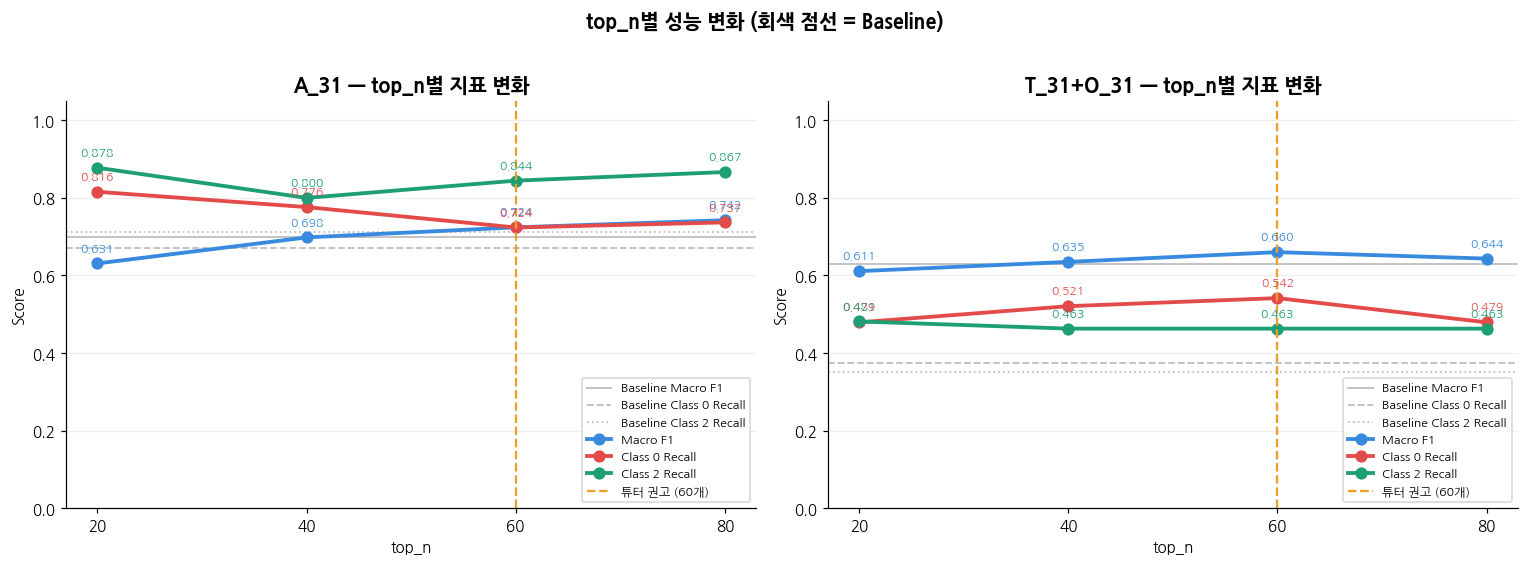


최종 권장 top_n:
  [A_31] F1 기준: top_n=80 | Class0 Recall 기준: top_n=20
  [T_31+O_31] F1 기준: top_n=60 | Class0 Recall 기준: top_n=60


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics = ['macro_f1', 'recall_0', 'recall_2']
metric_names = ['Macro F1', 'Class 0 Recall', 'Class 2 Recall']
colors = ['#378ADD', '#E24B4A', '#1D9E75', '#EF9F27']

for ax, product in zip(axes, ['A_31', 'T_31+O_31']):
    bl = BASELINE[product]
    for metric, mname, ls in zip(
        metrics, metric_names, ['-','--',':']
    ):
        ax.axhline(bl[metric], linestyle=ls, color='gray', alpha=0.5,
                   linewidth=1.2, label=f'Baseline {mname}')

    for i, (metric, mname, color) in enumerate(
        zip(metrics, metric_names, ['#378ADD','#E24B4A','#1D9E75'])
    ):
        vals = [topn_results[product][n][metric] for n in TOP_N_LIST]
        ax.plot(TOP_N_LIST, vals, color=color, linewidth=2.5,
                marker='o', markersize=7, label=mname)
        for n, v in zip(TOP_N_LIST, vals):
            ax.annotate(f'{v:.3f}', (n, v),
                        textcoords='offset points', xytext=(0, 8),
                        ha='center', fontsize=8, color=color)

    ax.axvline(60, color='#EF9F27', linestyle='--',
               linewidth=1.5, label='튜터 권고 (60개)')
    ax.set_xlabel('top_n')
    ax.set_ylabel('Score')
    ax.set_title(f'{product} — top_n별 지표 변화', fontsize=13, fontweight='bold')
    ax.set_xticks(TOP_N_LIST)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8, loc='lower right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.2)

plt.suptitle('top_n별 성능 변화 (회색 점선 = Baseline)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n최종 권장 top_n:')
for product in ['A_31', 'T_31+O_31']:
    best_n = max(topn_results[product].items(),
                 key=lambda x: x[1]['macro_f1'])[0]
    best_r0_n = max(topn_results[product].items(),
                    key=lambda x: x[1]['recall_0'])[0]
    print(f'  [{product}] F1 기준: top_n={best_n} | Class0 Recall 기준: top_n={best_r0_n}')